## 01 — Fourier Coefficients & Convergence

### Goal
1. Demonstrate orthogonality of {1, cos(nπx/L), sin(nπx/L)} on [-L, L].
2. Derive/compute Fourier coefficients of standard test functions.
3. Study convergence of the N-mode partial sum as N grows.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from src.fourier import FourierSeries

%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)

In [14]:
from pathlib import Path
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name, dpi=150):
    """Save a figure to figures/<name>.png and return the path."""
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"saved → {path.relative_to(PROJECT_ROOT)}")
    return path

## 1. Orthogonality check

For $m \neq n$:
$$\int_{-L}^{L} \cos\frac{m\pi x}{L}\cos\frac{n\pi x}{L}\,dx = 0$$

In [15]:
from scipy.integrate import quad

L = np.pi
def inner(f, g):
    val, _ = quad(lambda x: f(x) * g(x), -L, L, limit=200)
    return val

cos_m = lambda m: (lambda x: np.cos(m * np.pi * x / L))
sin_m = lambda m: (lambda x: np.sin(m * np.pi * x / L))

print("cos(1) · cos(2)  =", inner(cos_m(1), cos_m(2)))
print("sin(1) · sin(3)  =", inner(sin_m(1), sin_m(3)))
print("cos(1) · sin(1)  =", inner(cos_m(1), sin_m(1)))
print("cos(1) · cos(1)  =", inner(cos_m(1), cos_m(1)), "  (expected π = L)")

cos(1) · cos(2)  = -2.8056208054789386e-16
sin(1) · sin(3)  = -8.71967124502158e-17
cos(1) · sin(1)  = 0.0
cos(1) · cos(1)  = 3.1415926535897927   (expected π = L)


## 2. Test function: sawtooth wave
$$f(x) = x, \quad x \in [-\pi, \pi]$$

In [16]:
def sawtooth(x):
    return x

fs = FourierSeries(sawtooth, L=np.pi)
for N in [1, 3, 5, 10]:
    a0, an, bn = fs.compute_coefficients(N)
    print(f"N={N:2d} | a0={a0:+.4f} | a1={an[0]:+.4f} | b1={bn[0]:+.4f} "
          f"| b2={bn[1] if N>=2 else 0:+.4f}")

N= 1 | a0=+0.0000 | a1=+0.0000 | b1=+2.0000 | b2=+0.0000
N= 3 | a0=+0.0000 | a1=+0.0000 | b1=+2.0000 | b2=-1.0000
N= 5 | a0=+0.0000 | a1=+0.0000 | b1=+2.0000 | b2=-1.0000
N=10 | a0=+0.0000 | a1=+0.0000 | b1=+2.0000 | b2=-1.0000


Theory says for $f(x)=x$: $a_0 = 0$, $a_n = 0$, $b_n = \frac{2(-1)^{n+1}}{n}$.

saved → figures\01_convergence_sawtooth.png


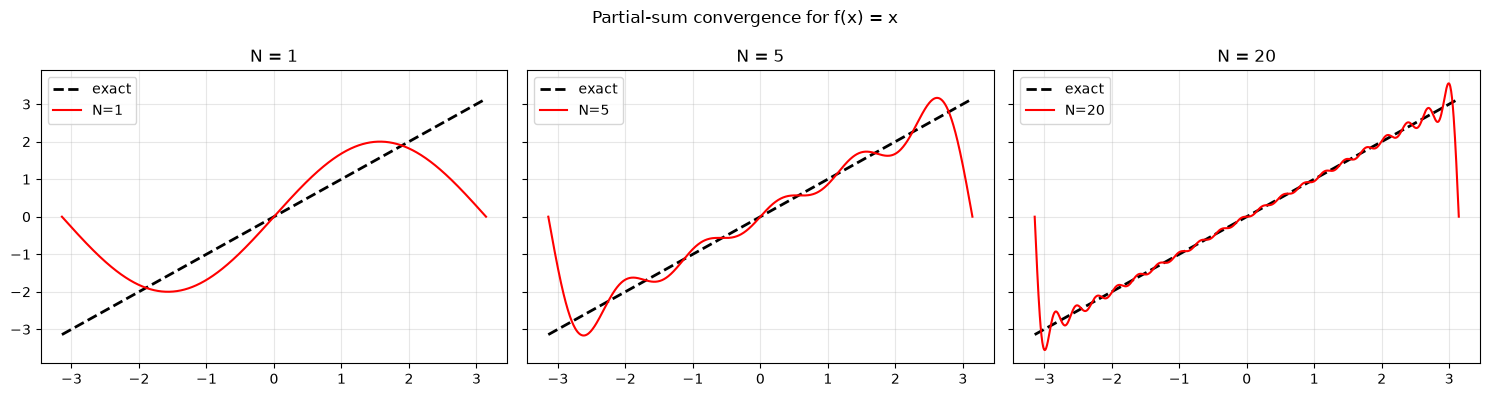

In [17]:

x = np.linspace(-np.pi, np.pi, 1000)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, N in zip(axes, [1, 5, 20]):
    ax.plot(x, sawtooth(x), "k--", lw=2, label="exact")
    ax.plot(x, fs.reconstruct(x, n_modes=N), "r", label=f"N={N}")
    ax.set_title(f"N = {N}")
    ax.legend()
    ax.grid(alpha=0.3)
fig.suptitle("Partial-sum convergence for f(x) = x")
fig.tight_layout()
save_fig(fig, "01_convergence_sawtooth")
plt.show()

## 3. Pointwise error decay

$L^\infty$ error should decay like $O(1/N)$ for a jump, $O(1/N^2)$ for a
continuous periodic function.

saved → figures\01_error_decay.png


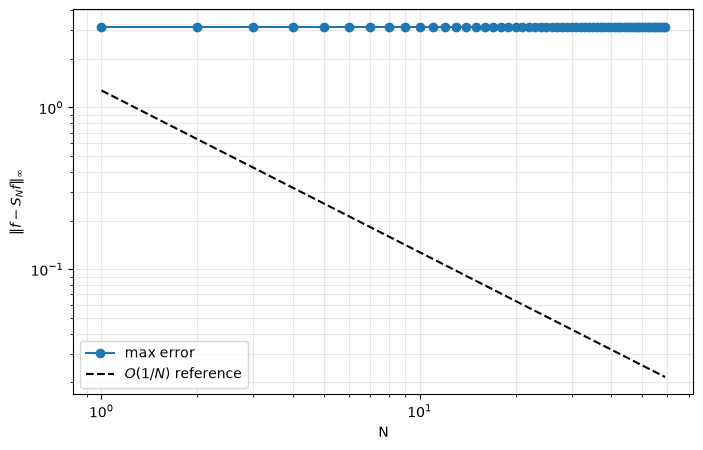

In [18]:
Ns = np.arange(1, 60)
errs = []
for N in Ns:
    y = fs.reconstruct(x, n_modes=N)
    errs.append(np.max(np.abs(y - sawtooth(x))))

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(Ns, errs, "o-", label="max error")
ax.loglog(Ns, 4/np.pi/Ns, "k--", label=r"$O(1/N)$ reference")
ax.set_xlabel("N"); ax.set_ylabel(r"$\|f - S_N f\|_\infty$")
ax.legend(); ax.grid(which="both", alpha=0.3)
save_fig(fig, "01_error_decay")
plt.show()

### Exercise
Repeat for $f(x) = x^2$ on $[-\pi,\pi]$ (extended periodically).
What is the decay rate now? Why?